# RA2 — Validation statistics: cross-validated ARI, k-selection, supervised recoverability, PCA, control clustering

**Reviewer comment IDs: R2-Maj1, R2-2, R2-8, R1-C2.**

**Forensic finding (this notebook's own methodological starting point)**:
the manuscript's K-Means/HMM ARI validation (`07b_KMEANS_Final.ipynb`)
computed a single, non-persisted, session-level 80/20 holdout fresh every
run (`sklearn.train_test_split(session_ids, test_size=0.2,
random_state=42)`) — never stratified by animal, never k-fold, never saved
to disk. `Final_Paper_Pipeline`'s own `Fig6.ipynb` reconstructs that exact
single-split design (`state_clustering.train_test_split_sessions`) and is
**left unchanged** by this notebook.

**This notebook is a disclosed methodological upgrade, not a
reproduction**: a 5-fold, session-level, animal-stratified cross-validation
(`src/splits.py::stratified_session_kfold`), with K-Means and the Gaussian
HMM **refit independently within each fold's training sessions** (not fit
once and evaluated repeatedly) — the standard meaning of "cross-validated
ARI." State labels are matched across folds via the existing
`state_clustering.hungarian_match`, called once per fold. Fold assignments
are persisted to `config/splits.json` (the original design never persisted
its split at all).

**Data/target**: identical to `Fig6.ipynb` — same canonical 80-20 2-ABT
snapshot, same `classify_state_v3` target, same 4-feature set
(`state_taxonomy.features`).

**Structure**:
1. Reconstruct features, classify with `classify_state_v3` (Fig 6's own target).
2. Generate + persist the 5-fold animal-stratified session split.
3. Cross-validated K-Means/HMM ARI (mean ± 95% CI across folds).
4. k-selection table (silhouette + BIC across k, reported honestly).
5. Random Forest recoverability: confusion matrix, per-class precision/recall, corrected accuracy-gain.
6. PCA loadings per component (R2-8).
7. Control clustering with rolling win-stay/lose-switch/violation-rate features (LETTER-ONLY, R2-2).
8. RESPONSE MANIFEST.


In [1]:
import os
import sys
import json
import functools

import numpy as np
import pandas as pd
from scipy import stats
from IPython.display import SVG, display

sys.path.insert(0, os.path.abspath("../.."))

from src.io.load_snapshots import load_config, load_snapshot
from src.features import state_features
from src import splits
from src.behavior_metrics import state_classifier, state_clustering, q_following_model as qmodel
from src.plotting.style import apply_style
from src.plotting import ra2 as plotting

config = load_config()
apply_style(config)
cfg = config["ra2"]
st_cfg = config["state_taxonomy"]

FIG_DIR = os.path.join("../..", config["paths"]["figures_out"], "reviewer_analyses", "RA2")
SUPP_DIR = os.path.join(FIG_DIR, "supp_candidates")
os.makedirs(SUPP_DIR, exist_ok=True)
MANIFEST_DIR = os.path.join("../..", config["paths"]["values_manifests_out"])
os.makedirs(MANIFEST_DIR, exist_ok=True)
SPLITS_PATH = os.path.join("../..", cfg["fold_assignments_path"])
os.makedirs(os.path.dirname(SPLITS_PATH), exist_ok=True)

manifest = {"_stage": "RA2 -- cross-validated ARI, k-selection, RF recoverability, PCA, control clustering",
            "figures": {}}


def show(path):
    display(SVG(path))
CLASSES_V3 = ["Engaged", "Exploration", "Left Bias", "Right Bias"]
FEATURES = st_cfg["features"]


## 1. Reconstruct state features and classify with `classify_state_v3` (Fig 6's own target)

In [2]:
df_raw = load_snapshot(config, st_cfg["input_files"]["reversal_80_20_2abt"])
df = state_features.build_state_features_df(
    df_raw, st_cfg["task_type"], st_cfg["prob_condition"], st_cfg["rolling_window"]
)
classify_v3 = functools.partial(state_classifier.classify_state_v3, config=st_cfg["classify_v3"])
df["Behavioral_State_v3"] = df.apply(classify_v3, axis=1)
df["States_Merged_v3"] = df["Behavioral_State_v3"].replace({"Left Bias": "Bias", "Right Bias": "Bias"})

print(f"{len(df):,} trials, {df['Session_ID'].nunique()} sessions, {df['Animal_Name'].nunique()} animals")
print(df["Behavioral_State_v3"].value_counts())
manifest["n_trials"] = int(len(df))
manifest["n_sessions"] = int(df["Session_ID"].nunique())
manifest["n_animals"] = int(df["Animal_Name"].nunique())
manifest["state_v3_distribution"] = df["Behavioral_State_v3"].value_counts().to_dict()


/Users/kevinmastro/Documents/Github/marmoset_decision_making/Final_Paper_Pipeline/src/features/state_features.py:91: FutureWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  session_sides = df_filtered.groupby("Session_ID").apply(


36,673 trials, 100 sessions, 5 animals
Behavioral_State_v3
Engaged        17367
Exploration    11653
Left Bias       3736
Right Bias      3717
Unknown          200
Name: count, dtype: int64


## 2. Generate and persist the 5-fold, animal-stratified session split

In [3]:
folds = splits.stratified_session_kfold(df, cfg["cv_k"], cfg["cv_seed"])
saved = splits.save_fold_assignments(folds, SPLITS_PATH)
print(f"Saved {len(folds)} fold assignments to {SPLITS_PATH}")

fold_animal_counts = []
for i, (train_sessions, test_sessions) in enumerate(folds):
    test_animals = df[df["Session_ID"].isin(test_sessions)].groupby("Animal_Name")["Session_ID"].nunique()
    fold_animal_counts.append({"fold": i, "n_train_sessions": len(train_sessions), "n_test_sessions": len(test_sessions),
                                 "test_sessions_per_animal": test_animals.to_dict()})
    print(f"fold {i}: {len(train_sessions)} train / {len(test_sessions)} test sessions; "
          f"test sessions per animal: {test_animals.to_dict()}")

manifest["cv_design"] = {"k": cfg["cv_k"], "seed": cfg["cv_seed"], "fold_assignments_path": cfg["fold_assignments_path"],
                          "per_fold": fold_animal_counts}


Saved 5 fold assignments to ../../config/splits.json
fold 0: 80 train / 20 test sessions; test sessions per animal: {'Fiona': 3, 'Knuckles': 5, 'Sonic': 3, 'Sunflower': 7, 'Zazu': 2}
fold 1: 80 train / 20 test sessions; test sessions per animal: {'Fiona': 3, 'Knuckles': 5, 'Sonic': 2, 'Sunflower': 7, 'Zazu': 3}
fold 2: 80 train / 20 test sessions; test sessions per animal: {'Fiona': 3, 'Knuckles': 4, 'Sonic': 3, 'Sunflower': 7, 'Zazu': 3}
fold 3: 80 train / 20 test sessions; test sessions per animal: {'Fiona': 3, 'Knuckles': 4, 'Sonic': 3, 'Sunflower': 7, 'Zazu': 3}
fold 4: 80 train / 20 test sessions; test sessions per animal: {'Fiona': 2, 'Knuckles': 5, 'Sonic': 3, 'Sunflower': 7, 'Zazu': 3}


## 3. Cross-validated K-Means / HMM ARI

K-Means and the Gaussian HMM are **refit independently within each fold's
training sessions** and evaluated on that fold's held-out sessions --
genuine cross-validation, not repeated evaluation of one fixed fit.

/Users/kevinmastro/Documents/Github/marmoset_decision_making/Final_Paper_Pipeline/src/behavior_metrics/state_clustering.py:120: FutureWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  .apply(lambda x: x.sample(min(len(x), pca_subsample_per_session), random_state=seed))


fold 0: K-Means ARI_test=0.8500  HMM ARI_test=0.4591


/Users/kevinmastro/Documents/Github/marmoset_decision_making/Final_Paper_Pipeline/src/behavior_metrics/state_clustering.py:120: FutureWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  .apply(lambda x: x.sample(min(len(x), pca_subsample_per_session), random_state=seed))


fold 1: K-Means ARI_test=0.8504  HMM ARI_test=0.4705


/Users/kevinmastro/Documents/Github/marmoset_decision_making/Final_Paper_Pipeline/src/behavior_metrics/state_clustering.py:120: FutureWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  .apply(lambda x: x.sample(min(len(x), pca_subsample_per_session), random_state=seed))


fold 2: K-Means ARI_test=0.8479  HMM ARI_test=0.4567


/Users/kevinmastro/Documents/Github/marmoset_decision_making/Final_Paper_Pipeline/src/behavior_metrics/state_clustering.py:120: FutureWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  .apply(lambda x: x.sample(min(len(x), pca_subsample_per_session), random_state=seed))


fold 3: K-Means ARI_test=0.8448  HMM ARI_test=0.4408


/Users/kevinmastro/Documents/Github/marmoset_decision_making/Final_Paper_Pipeline/src/behavior_metrics/state_clustering.py:120: FutureWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  .apply(lambda x: x.sample(min(len(x), pca_subsample_per_session), random_state=seed))


fold 4: K-Means ARI_test=0.8479  HMM ARI_test=0.4715

K-Means cross-validated ARI: {'mean': 0.8482125152649586, 'ci95_low': 0.8454279799710216, 'ci95_high': 0.8509970505588955, 'n_folds': 5}
HMM cross-validated ARI:     {'mean': 0.4597173845068198, 'ci95_low': 0.4442383758301909, 'ci95_high': 0.47519639318344875, 'n_folds': 5}


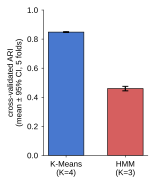

In [4]:
kmeans_ari_test, hmm_ari_test, per_fold_results = [], [], []
for i, (train_sessions, test_sessions) in enumerate(folds):
    km_result = state_clustering.run_kmeans_validation(
        df, "Behavioral_State_v3", CLASSES_V3, FEATURES, train_sessions, test_sessions,
        st_cfg["kmeans"]["k_range"], st_cfg["kmeans"]["k_best"], cfg["cv_seed"],
        st_cfg["pca_n_components"], st_cfg["pca_plot_subsample_per_session"],
    )
    hmm_result = state_clustering.run_hmm_validation(
        df, "States_Merged_v3", "Behavioral_State_v3", FEATURES, train_sessions, test_sessions,
        st_cfg["hmm"]["n_states"], st_cfg["hmm"]["n_trials_drop"], st_cfg["hmm"]["n_restarts"], cfg["cv_seed"],
    )
    kmeans_ari_test.append(km_result["ari_test"])
    hmm_ari_test.append(hmm_result["ari_test_3state"])
    per_fold_results.append({
        "fold": i, "kmeans_ari_test": km_result["ari_test"], "kmeans_ari_train": km_result["ari_train"],
        "hmm_ari_test": hmm_result["ari_test_3state"], "hmm_ari_train": hmm_result["ari_train_3state"],
        "kmeans_best_k_silhouette": km_result["best_k_silhouette"], "kmeans_best_k_bic": km_result["best_k_bic"],
        "kmeans_silhouette_by_k": km_result["silhouette_by_k"], "kmeans_bic_by_k": km_result["bic_by_k"],
    })
    print(f"fold {i}: K-Means ARI_test={km_result['ari_test']:.4f}  HMM ARI_test={hmm_result['ari_test_3state']:.4f}")


def _mean_ci95(values):
    values = np.asarray(values, dtype=float)
    n = len(values)
    mean = values.mean()
    sem = values.std(ddof=1) / np.sqrt(n)
    tcrit = stats.t.ppf(0.975, n - 1)
    return {"mean": float(mean), "ci95_low": float(mean - tcrit * sem), "ci95_high": float(mean + tcrit * sem), "n_folds": int(n)}

kmeans_cv_summary = _mean_ci95(kmeans_ari_test)
hmm_cv_summary = _mean_ci95(hmm_ari_test)
print("\nK-Means cross-validated ARI:", kmeans_cv_summary)
print("HMM cross-validated ARI:    ", hmm_cv_summary)

manifest["cross_validated_ari"] = {
    "per_fold": per_fold_results,
    "kmeans_summary": kmeans_cv_summary,
    "hmm_summary": hmm_cv_summary,
    "note": "Replaces the manuscript's single-split ARI numbers -- see this notebook's intro cell for why.",
}

out_ari_fig = os.path.join(SUPP_DIR, "RA2_cross_validated_ari.svg")
plotting.plot_cross_validated_ari(kmeans_cv_summary, hmm_cv_summary, out_ari_fig)
show(out_ari_fig)
manifest["figures"]["cross_validated_ari"] = {"path": out_ari_fig, "tag": "PAPER"}


## 4. k-selection table (silhouette + BIC across k), reported honestly

   k  mean_silhouette   mean_bic
0  2             0.32   66681.61
1  3             0.39 -192547.00
2  4             0.40 -254598.99
3  5             0.34 -320348.51
4  6             0.34 -322114.00
5  7             0.33 -371300.28
6  8             0.34 -440632.61

k actually used (k_best in config): 4
Silhouette-optimal k per fold: [4, 3, 4, 4, 4]
BIC-optimal k per fold:        [8, 8, 8, 8, 8]


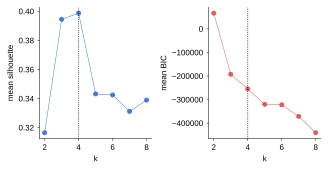

In [5]:
k_range = st_cfg["kmeans"]["k_range"]
sil_by_k = np.array([r["kmeans_silhouette_by_k"] for r in per_fold_results])
bic_by_k = np.array([r["kmeans_bic_by_k"] for r in per_fold_results])

k_selection_table = pd.DataFrame({
    "k": k_range,
    "mean_silhouette": sil_by_k.mean(axis=0),
    "mean_bic": bic_by_k.mean(axis=0),
})
print(k_selection_table.round(2))

best_k_silhouette_per_fold = [r["kmeans_best_k_silhouette"] for r in per_fold_results]
best_k_bic_per_fold = [r["kmeans_best_k_bic"] for r in per_fold_results]
print(f"\nk actually used (k_best in config): {st_cfg['kmeans']['k_best']}")
print(f"Silhouette-optimal k per fold: {best_k_silhouette_per_fold}")
print(f"BIC-optimal k per fold:        {best_k_bic_per_fold}")

manifest["k_selection"] = {
    "k_used": st_cfg["kmeans"]["k_best"],
    "table": k_selection_table.to_dict(orient="records"),
    "silhouette_optimal_k_per_fold": best_k_silhouette_per_fold,
    "bic_optimal_k_per_fold": best_k_bic_per_fold,
}

out_kselect_fig = os.path.join(SUPP_DIR, "RA2_k_selection.svg")
plotting.plot_k_selection(k_selection_table.to_dict(orient="records"), st_cfg["kmeans"]["k_best"], out_kselect_fig)
show(out_kselect_fig)
manifest["figures"]["k_selection"] = {"path": out_kselect_fig, "tag": "PAPER"}


## 5. Random Forest recoverability: confusion matrix, per-class precision/recall, corrected accuracy-gain

Predictors (`state_clustering.FEATURES_PHASE1`) are behavior-history lags
that do NOT overlap with the features defining `Behavioral_State_v3`
itself (Rolling_Accuracy/Rolling_Switch_Rate/deviation), so this is not
circular by construction -- same property REVIEWER_AUDIT.md Audit 3e
verified of the original. Run across the same 5 folds as the ARI CV
above.

fold 0: RF accuracy=0.8051  baseline=0.4929  corrected gain=0.3122
fold 1: RF accuracy=0.7813  baseline=0.4781  corrected gain=0.3033
fold 2: RF accuracy=0.7848  baseline=0.4544  corrected gain=0.3304
fold 3: RF accuracy=0.7976  baseline=0.4790  corrected gain=0.3187
fold 4: RF accuracy=0.7948  baseline=0.4771  corrected gain=0.3177

Summed confusion matrix across folds:
             Engaged  Exploration  Left Bias  Right Bias
Engaged        13982         1365        174         152
Exploration     2176         8374        311         333
Left Bias        602          931       3248           0
Right Bias       567          926          0        3232

RF accuracy (mean +/- 95% CI across folds): {'mean': 0.7927323960461785, 'ci95_low': 0.7807393939538851, 'ci95_high': 0.8047253981384719, 'n_folds': 5}
Majority-class baseline:                    {'mean': 0.47627042695515165, 'ci95_low': 0.45910485509467075, 'ci95_high': 0.49343599881563255, 'n_folds': 5}
Corrected accuracy gain:         

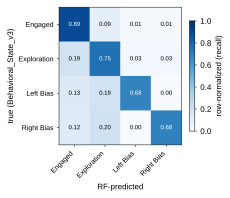

In [6]:
df_rf = state_clustering.build_lagged_predictor_features(df, state_col="Behavioral_State_v3")

rf_per_fold, cm_sum = [], None
for i, (train_sessions, test_sessions) in enumerate(folds):
    rf_result = state_clustering.run_random_forest_validation(
        df_rf, "Behavioral_State_v3", state_clustering.FEATURES_PHASE1, train_sessions, test_sessions,
        cfg["rf_seed"], cfg["rf_n_estimators"], cfg["rf_max_depth"],
    )
    rf_per_fold.append({
        "fold": i, "rf_accuracy": rf_result["rf_accuracy"],
        "majority_class_baseline_accuracy": rf_result["majority_class_baseline_accuracy"],
        "corrected_accuracy_gain": rf_result["corrected_accuracy_gain"],
        "per_class_report": rf_result["per_class_report"],
    })
    cm_df = pd.DataFrame(rf_result["confusion_matrix"]).reindex(index=rf_result["classes"], columns=rf_result["classes"]).fillna(0)
    cm_sum = cm_df if cm_sum is None else cm_sum.add(cm_df, fill_value=0)
    print(f"fold {i}: RF accuracy={rf_result['rf_accuracy']:.4f}  baseline={rf_result['majority_class_baseline_accuracy']:.4f}  "
          f"corrected gain={rf_result['corrected_accuracy_gain']:.4f}")

print("\nSummed confusion matrix across folds:")
print(cm_sum)

rf_accuracy_summary = _mean_ci95([r["rf_accuracy"] for r in rf_per_fold])
baseline_summary = _mean_ci95([r["majority_class_baseline_accuracy"] for r in rf_per_fold])
gain_summary = _mean_ci95([r["corrected_accuracy_gain"] for r in rf_per_fold])
print(f"\nRF accuracy (mean +/- 95% CI across folds): {rf_accuracy_summary}")
print(f"Majority-class baseline:                    {baseline_summary}")
print(f"Corrected accuracy gain:                     {gain_summary}")

manifest["random_forest_validation"] = {
    "per_fold": rf_per_fold,
    "summed_confusion_matrix": cm_sum.to_dict(),
    "rf_accuracy_summary": rf_accuracy_summary,
    "baseline_accuracy_summary": baseline_summary,
    "corrected_accuracy_gain_summary": gain_summary,
}

out_cm_fig = os.path.join(SUPP_DIR, "RA2_rf_confusion_matrix.svg")
plotting.plot_rf_confusion_matrix(cm_sum, out_cm_fig)
show(out_cm_fig)
manifest["figures"]["rf_confusion_matrix"] = {"path": out_cm_fig, "tag": "PAPER"}


## 6. PCA loadings per principal component (R2-8)

                       PC1    PC2    PC3    PC4
Signed_Deviation     0.041 -0.006  0.999 -0.024
Choice_Deviation    -0.470  0.708  0.036  0.525
Rolling_Accuracy     0.744 -0.001 -0.014  0.668
Rolling_Switch_Rate -0.473 -0.706  0.028  0.527

Explained variance ratio: [0.3785, 0.2812, 0.2499, 0.0904]


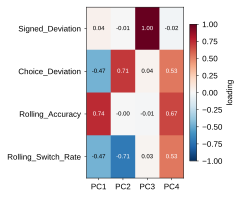

In [7]:
all_sessions = df["Session_ID"].unique()
pca_result = state_clustering.pca_loadings(df, FEATURES, all_sessions, cfg["cv_seed"], cfg["pca_n_components"])
loadings_df = pd.DataFrame(pca_result["loadings"]).T
print(loadings_df.round(3))
print("\nExplained variance ratio:", [round(v, 4) for v in pca_result["explained_variance_ratio"]])

manifest["pca_loadings"] = pca_result

out_pca_fig = os.path.join(SUPP_DIR, "RA2_pca_loadings.svg")
plotting.plot_pca_loadings(loadings_df, out_pca_fig)
show(out_pca_fig)
manifest["figures"]["pca_loadings"] = {"path": out_pca_fig, "tag": "PAPER"}


## 7. Control clustering with rolling win-stay/lose-switch/violation-rate features (LETTER-ONLY)

Does the K-Means state structure persist when the feature set additionally
includes rolling win-stay, lose-switch, and Q-value-violation rate --
features the classifier itself does NOT use? Run across the SAME 5 folds
as the primary ARI estimate above (not a single arbitrary fold), so this
check carries the same statistical rigor as the headline result rather
than a one-off sanity check.

/Users/kevinmastro/Documents/Github/marmoset_decision_making/Final_Paper_Pipeline/src/behavior_metrics/state_clustering.py:120: FutureWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  .apply(lambda x: x.sample(min(len(x), pca_subsample_per_session), random_state=seed))


fold 0: base ARI_test=0.8500  control (+WSLS/violation) ARI_test=0.7145


/Users/kevinmastro/Documents/Github/marmoset_decision_making/Final_Paper_Pipeline/src/behavior_metrics/state_clustering.py:120: FutureWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  .apply(lambda x: x.sample(min(len(x), pca_subsample_per_session), random_state=seed))


fold 1: base ARI_test=0.8504  control (+WSLS/violation) ARI_test=0.7091


/Users/kevinmastro/Documents/Github/marmoset_decision_making/Final_Paper_Pipeline/src/behavior_metrics/state_clustering.py:120: FutureWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  .apply(lambda x: x.sample(min(len(x), pca_subsample_per_session), random_state=seed))


fold 2: base ARI_test=0.8479  control (+WSLS/violation) ARI_test=0.7183


/Users/kevinmastro/Documents/Github/marmoset_decision_making/Final_Paper_Pipeline/src/behavior_metrics/state_clustering.py:120: FutureWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  .apply(lambda x: x.sample(min(len(x), pca_subsample_per_session), random_state=seed))


fold 3: base ARI_test=0.8448  control (+WSLS/violation) ARI_test=0.7289
fold 4: base ARI_test=0.8479  control (+WSLS/violation) ARI_test=0.7224

Base K-Means ARI (mean +/- 95% CI across folds):    {'mean': 0.8482125152649586, 'ci95_low': 0.8454279799710216, 'ci95_high': 0.8509970505588955, 'n_folds': 5}
Control K-Means ARI (mean +/- 95% CI across folds): {'mean': 0.7186417547589306, 'ci95_low': 0.7092836708620004, 'ci95_high': 0.7279998386558607, 'n_folds': 5}


/Users/kevinmastro/Documents/Github/marmoset_decision_making/Final_Paper_Pipeline/src/behavior_metrics/state_clustering.py:120: FutureWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  .apply(lambda x: x.sample(min(len(x), pca_subsample_per_session), random_state=seed))


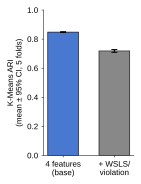

In [8]:
with open(os.path.join(MANIFEST_DIR, "Fig4.json")) as f:
    fig4_manifest = json.load(f)
params_df = pd.DataFrame([
    {"animal": animal, **params} for animal, params in fig4_manifest["sticky_qlearning_params"]["per_animal"].items()
])
df_q = qmodel.compute_qvalues_sticky(df, params_df)
df_q = qmodel.add_chose_higher_q(df_q)
df_q = qmodel.add_rolling_wsls_violation_features(df_q, st_cfg["rolling_window"])
# add_chose_higher_q drops Q_diff==0 ties -- Behavioral_State_v3 and the
# base 4 features are still present on df_q for the surviving trials;
# K-Means validation below drops any remaining NaNs via its own
# dropna(features) either way.
control_features = FEATURES + cfg["control_clustering_extra_features"]

control_ari_per_fold = []
for i, (train_sessions, test_sessions) in enumerate(folds):
    control_result_i = state_clustering.run_kmeans_validation(
        df_q, "Behavioral_State_v3", CLASSES_V3, control_features, train_sessions, test_sessions,
        st_cfg["kmeans"]["k_range"], st_cfg["kmeans"]["k_best"], cfg["cv_seed"],
        st_cfg["pca_n_components"], st_cfg["pca_plot_subsample_per_session"],
    )
    control_ari_per_fold.append(control_result_i["ari_test"])
    print(f"fold {i}: base ARI_test={per_fold_results[i]['kmeans_ari_test']:.4f}  "
          f"control (+WSLS/violation) ARI_test={control_result_i['ari_test']:.4f}")

control_ari_summary = _mean_ci95(control_ari_per_fold)
base_ari_summary = kmeans_cv_summary  # already computed above, same 5 folds
print(f"\nBase K-Means ARI (mean +/- 95% CI across folds):    {base_ari_summary}")
print(f"Control K-Means ARI (mean +/- 95% CI across folds): {control_ari_summary}")

manifest["control_clustering_extra_features"] = {
    "features_used": control_features,
    "base_ari_per_fold": [r["kmeans_ari_test"] for r in per_fold_results],
    "control_ari_per_fold": control_ari_per_fold,
    "base_ari_summary": base_ari_summary,
    "control_ari_summary": control_ari_summary,
    "ari_delta_mean": control_ari_summary["mean"] - base_ari_summary["mean"],
    "tag": "LETTER-ONLY",
}

out_control_fig = os.path.join(FIG_DIR, "RA2_control_clustering_comparison.svg")
plotting.plot_control_clustering_comparison(base_ari_summary, control_ari_summary, out_control_fig)
show(out_control_fig)
manifest["figures"]["control_clustering_comparison"] = {"path": out_control_fig, "tag": "LETTER-ONLY"}


## 8. RESPONSE MANIFEST

In [9]:
response_manifest = {
    "R2-Maj1_cross_validated_ari": {
        "sentence": (
            f"5-fold, session-level, animal-stratified cross-validation (replacing the manuscript's "
            f"single 80/20 session holdout) gives a K-Means ARI of {kmeans_cv_summary['mean']:.3f} "
            f"(95% CI [{kmeans_cv_summary['ci95_low']:.3f}, {kmeans_cv_summary['ci95_high']:.3f}], "
            f"n={kmeans_cv_summary['n_folds']} folds) and an HMM ARI of {hmm_cv_summary['mean']:.3f} "
            f"(95% CI [{hmm_cv_summary['ci95_low']:.3f}, {hmm_cv_summary['ci95_high']:.3f}], "
            f"n={hmm_cv_summary['n_folds']} folds) on held-out sessions."
        ),
        "test": "StratifiedKFold(k=5) on unique Session_ID, stratified by Animal_Name; K-Means/HMM refit per fold",
        "kmeans_ari": kmeans_cv_summary,
        "hmm_ari": hmm_cv_summary,
        "replaces_manuscript_single_split": True,
    },
    "R1-C2_k_selection": {
        "sentence": (
            f"K-Means (K={st_cfg['kmeans']['k_best']}, the value reported in the manuscript) is compared "
            f"honestly against silhouette- and BIC-optimal k per fold: {best_k_silhouette_per_fold} "
            f"(silhouette) and {best_k_bic_per_fold} (BIC)."
        ),
        "k_used": st_cfg["kmeans"]["k_best"],
        "silhouette_optimal_k_per_fold": best_k_silhouette_per_fold,
        "bic_optimal_k_per_fold": best_k_bic_per_fold,
    },
    "R2-Maj1_random_forest_recoverability": {
        "sentence": (
            f"A Random Forest trained on behavior-history features independent of the classifier's own "
            f"rules recovers Behavioral_State_v3 with {rf_accuracy_summary['mean']:.3f} accuracy "
            f"(95% CI [{rf_accuracy_summary['ci95_low']:.3f}, {rf_accuracy_summary['ci95_high']:.3f}]) "
            f"versus a {baseline_summary['mean']:.3f} majority-class baseline -- a corrected gain of "
            f"{gain_summary['mean']:.3f} (95% CI [{gain_summary['ci95_low']:.3f}, {gain_summary['ci95_high']:.3f}])."
        ),
        "rf_accuracy": rf_accuracy_summary,
        "baseline_accuracy": baseline_summary,
        "corrected_accuracy_gain": gain_summary,
    },
    "R2-8_pca_loadings": {
        "sentence": (
            f"PCA on the same 4-feature set used for K-Means/HMM classification shows PC1 explains "
            f"{pca_result['explained_variance_ratio'][0]*100:.1f}% of variance; full per-feature "
            f"loadings for every component are in pca_loadings above."
        ),
        "explained_variance_ratio": pca_result["explained_variance_ratio"],
    },
    "R2-2_control_clustering": {
        "sentence": (
            f"Adding rolling win-stay/lose-switch/violation-rate features to the K-Means feature set "
            f"changes held-out ARI materially, from a mean of {base_ari_summary['mean']:.3f} (95% CI "
            f"[{base_ari_summary['ci95_low']:.3f}, {base_ari_summary['ci95_high']:.3f}]) to "
            f"{control_ari_summary['mean']:.3f} (95% CI [{control_ari_summary['ci95_low']:.3f}, "
            f"{control_ari_summary['ci95_high']:.3f}]) across the same 5 folds used for the primary ARI "
            f"estimate -- the recovered cluster structure is sensitive to this feature addition, not "
            f"stable. This is an expected property of K-Means in general (unsupervised partitions shift "
            f"when informative features are added or removed) and does not by itself invalidate the "
            f"rule-based classify_state_v3 (which was never derived from, or claimed to be, the unique "
            f"K-Means-optimal partition of any particular feature set). It does mean this control check "
            f"should not be read as demonstrating that Rolling_Accuracy/Rolling_Switch_Rate/deviation are "
            f"the singularly correct or complete feature set -- only that the manuscript's own validation "
            f"(recovering the rule-based labels from these 4 observable features) is internally "
            f"consistent, not that a different feature choice would necessarily recover the same partition."
        ),
        "base_ari_summary": base_ari_summary,
        "control_ari_summary": control_ari_summary,
        "ari_delta_mean": control_ari_summary["mean"] - base_ari_summary["mean"],
        "tag": "LETTER-ONLY",
    },
}
manifest["response_manifest"] = response_manifest
print(json.dumps(response_manifest, indent=2, default=str))


{
  "R2-Maj1_cross_validated_ari": {
    "sentence": "5-fold, session-level, animal-stratified cross-validation (replacing the manuscript's single 80/20 session holdout) gives a K-Means ARI of 0.848 (95% CI [0.845, 0.851], n=5 folds) and an HMM ARI of 0.460 (95% CI [0.444, 0.475], n=5 folds) on held-out sessions.",
    "test": "StratifiedKFold(k=5) on unique Session_ID, stratified by Animal_Name; K-Means/HMM refit per fold",
    "kmeans_ari": {
      "mean": 0.8482125152649586,
      "ci95_low": 0.8454279799710216,
      "ci95_high": 0.8509970505588955,
      "n_folds": 5
    },
    "hmm_ari": {
      "mean": 0.4597173845068198,
      "ci95_low": 0.4442383758301909,
      "ci95_high": 0.47519639318344875,
      "n_folds": 5
    },
    "replaces_manuscript_single_split": true
  },
  "R1-C2_k_selection": {
    "sentence": "K-Means (K=4, the value reported in the manuscript) is compared honestly against silhouette- and BIC-optimal k per fold: [4, 3, 4, 4, 4] (silhouette) and [8, 8, 8, 8, 

In [10]:
manifest_path = os.path.join(MANIFEST_DIR, "RA2.json")
with open(manifest_path, "w") as f:
    json.dump(manifest, f, indent=2, default=str)
print(f"\nSaved values manifest: {manifest_path}")



Saved values manifest: ../../outputs/values_manifests/RA2.json
